In [1]:
import logging
import os
import re
from pathlib import Path
from statistics import median
from typing import Dict, Any, List, Optional, Tuple

import pandas as pd
import numpy as np
from napistu.utils import load_pickle, save_pickle
import matplotlib.pyplot as plt
import seaborn as sns

from napistu_torch.load.foundation_models import AttendedEmbeddingsSet, FoundationModel, FoundationModels, _get_disk_name
from napistu_torch.utils.tensor_utils import compute_correlation_matrix
from napistu_torch.utils.torch_utils import cleanup_tensors, ensure_device
from napistu_torch.load.constants import MODEL_NICE_NAMES
from napistu_torch.utils.statistics import compare_top_k_union_ranks
from napistu_torch.utils.pd_utils import reorder_multindex_by_categorical_and_numeric
from napistu_torch.utils.napistu_utils import map_identifiers_to_vertex_names
from napistu_torch.visualization.heatmaps import plot_heatmap

logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s')
logger = logging.getLogger(__name__)

CONSENSUS_METHOD = "sum"
BY_ABSOLUTE_VALUE = False
VERBOSE = False
TOP_K = 10000
IGNORE_SELF_ATTENTION = True
DEVICE = ensure_device(None, allow_autoselect=True)
OVERWRITE = False

CACHE_DIR = Path("~/Desktop/DATA").expanduser()
EMBEDDING_DATASET = "efthymiou2025"
OUTPUT_DIR = "output"

INCLUDE_SCGPT = False
SCGPT_MODEL_NAME = "scGPT" # process with and without scGPT since scGPT only uses the top 1200 highly variable genes
IGNORE_CATEGORIES_WITH = ["unknown"]

def to_filename(s: str) -> str:
    s = re.sub(r'[^\w\s-]', '', s)
    s = re.sub(r'\s+', '_', s)
    return s.strip('-_')


def get_cache_path(dataset: str, category: str, include_scgpt: bool) -> Path:
    scgpt_flag = "with_scgpt" if include_scgpt else "without_scgpt"
    return CACHE_DIR / f"comparisons_{dataset}_{to_filename(category)}_{scgpt_flag}.pkl"


def get_model_prefixes(include_scgpt: bool = True) -> List[str]:
    return [
        _get_disk_name(model_name, model_variant)
        for model_name, model_variant in MODEL_NICE_NAMES
        if include_scgpt or model_name != SCGPT_MODEL_NAME
    ]

def get_all_categories(
    output_dir: str = OUTPUT_DIR,
    embedding_dataset: str = EMBEDDING_DATASET,
    ignore_categories_with: List[str] = IGNORE_CATEGORIES_WITH,
) -> List[str]:
    fms = FoundationModels.load_multiple(output_dir, get_model_prefixes(), verbose = False)

    first_model_keys = fms.models[0].dataset_gene_embeddings.get(embedding_dataset).keys()
    other_model_keys = [set(x.dataset_gene_embeddings.get(embedding_dataset).keys()) for x in fms.models[1:]]

    all_categories = [k for k in first_model_keys if all(k in s for s in other_model_keys)]

    # filter categories to exclude categories containing substrings from IGNORE_CATEGORIES_WITH
    valid_categories = [cat for cat in all_categories if not any(substring in cat for substring in ignore_categories_with)]

    return valid_categories


def compare_foundation_models(
    attended_embeddings_set: AttendedEmbeddingsSet,
    top_k: int,
    consensus_method: str,
    by_absolute_value: bool,
    ignore_self_attention: bool,
    verbose: bool,
) -> Dict[str, Any]:

    # precalculate and cache operations that take more than a minute or so
    comparisons = dict()

    # gene embedding correlations
    logger.info("Calculating gene embedding correlations...")
    comparisons["gene_embedding_correlations"] = attended_embeddings_set.embeddings_set.compare_embeddings(verbose = verbose)

    # within model layer x layer comparisons (correlations and rank agreement)
    logger.info("Calculating within model layer x layer comparisons...")
    comparisons["model_layer_correlations"], comparisons["model_layer_rank_agreement"] = (
        _get_within_model_layer_x_layer_comparison(attended_embeddings_set, top_k, ignore_self_attention, by_absolute_value, verbose)
    )

    # cross model x layer top attentions
    logger.info("Calculating cross model x layer top attentions...")
    comparisons["cross_model_x_layer_top_attentions"] = (
        attended_embeddings_set.get_top_attentions(
            k = top_k,
            by_absolute_value = by_absolute_value,
            reextract_union = True,
            compute_ranks = True,
            ignore_self_attention = ignore_self_attention,
            verbose = verbose,
    ))

    logger.info("Comparing ranks of topK attentions in one model/layer to all other models/layers...")
    n_genes = attended_embeddings_set.n_common_genes
    comparisons["cross_model_x_layer_rank_agreement"] = compare_top_k_union_ranks(
        comparisons["cross_model_x_layer_top_attentions"],
        grouping_vars = ["model", "layer"],
        defining_vars = ["from_gene", "to_gene"],
        max_rank = n_genes ** 2,
        top_k = TOP_K,
        rank_col = "attention_rank"
    )

    logger.info("Calculating cross model consensus top attentions...")
    comparisons["cross_model_consensus_top_attentions"] = (
        attended_embeddings_set.get_consensus_top_attentions(
            k = top_k,
            consensus_method = consensus_method,
            by_absolute_value = by_absolute_value,
            reextract_union = True,
            compute_ranks = True,
            ignore_self_attention = ignore_self_attention,
            verbose = verbose,
    ))

    comparisons["cross_model_consensus_top_attentions_rank_agreement"] = compare_top_k_union_ranks(
        comparisons["cross_model_consensus_top_attentions"],
        grouping_vars = ["model"],
        defining_vars = ["from_gene", "to_gene"],
        max_rank = n_genes ** 2,
        top_k = TOP_K,
        rank_col = "attention_rank"
    )

    comparisons["settings"] = {
        "top_k": top_k,
        "consensus_method": consensus_method,
        "by_absolute_value": by_absolute_value,
        "ignore_self_attention": ignore_self_attention,
        "embedding_keys": attended_embeddings_set.embedding_keys,
        "n_genes": n_genes
    }

    return comparisons


def _get_within_model_layer_x_layer_comparison(
    attended_embeddings_set: AttendedEmbeddingsSet,
    top_k: int,
    ignore_self_attention: bool,
    by_absolute_value: bool,
    verbose: bool,
) -> Tuple[Dict[str, Any], Dict[str, Any]]:

    if not isinstance(attended_embeddings_set, AttendedEmbeddingsSet):
        raise ValueError("attended_embeddings_set must be an instance of AttendedEmbeddingsSet")

    model_layer_correlations = {}
    model_layer_rank_agreement = {}

    for an_attended_embedding in attended_embeddings_set.attended_embeddings.values():

        model_name = an_attended_embedding.model_name
        logger.info(f"Summarizing cross-layer attention consistency for {model_name}...")

        model_layer_correlations[model_name], model_layer_rank_agreement[model_name] = an_attended_embedding.compare_layer_attention_consistency(
            top_k = top_k,
            ignore_self_attention = ignore_self_attention,
            by_absolute_value = by_absolute_value,
            verbose = verbose
        )
        
    return model_layer_correlations, model_layer_rank_agreement


def validate_results_against_current_settings(
    results: Dict[str, Any],
    top_k: int,
    consensus_method: str,
    by_absolute_value: bool,
    ignore_self_attention: bool,
    embedding_keys: Optional[List[str]] = None,
) -> None:

    # check compatibility between the loaded results and the current settings
    if top_k != results["settings"]["top_k"]:
        logger.warning(f"TOP_K mismatch: {TOP_K} != {results['settings']['top_k']}")
    if consensus_method != results["settings"]["consensus_method"]:
        logger.warning(f"CONSENSUS_METHOD mismatch: {CONSENSUS_METHOD} != {results['settings']['consensus_method']}")
    if by_absolute_value != results["settings"]["by_absolute_value"]:
        logger.warning(f"BY_ABSOLUTE_VALUE mismatch: {BY_ABSOLUTE_VALUE} != {results['settings']['by_absolute_value']}")
    if ignore_self_attention != results["settings"]["ignore_self_attention"]:
        logger.warning(f"IGNORE_SELF_ATTENTION mismatch: {IGNORE_SELF_ATTENTION} != {results['settings']['ignore_self_attention']}")
    if embedding_keys is not None:
        if set(embedding_keys) != set(results["settings"]["embedding_keys"]):
            extra_models = set(results["settings"]["embedding_keys"]) - set(embedding_keys)
            missing_models = set(embedding_keys) - set(results["settings"]["embedding_keys"])
            logger.warning(f"Extra models: {extra_models}")
            logger.warning(f"Missing models: {missing_models}")

In [2]:
from napistu_torch.napistu_data_store import NapistuDataStore
from napistu.constants import BQB_DEFINING_ATTRS_LOOSE
from napistu_torch.load.constants import DEFAULT_ARTIFACTS_NAMES

STORE_DIR = os.path.expanduser("~/Desktop/EXPERIMENTS/.store")
napistu_data_store = NapistuDataStore(STORE_DIR)
species_identifiers = (
    napistu_data_store.load_pandas_df(DEFAULT_ARTIFACTS_NAMES.SPECIES_IDENTIFIERS)
    .query("bqb in @BQB_DEFINING_ATTRS_LOOSE") # filter complexes (which would could contain a protein with a BQB_HAS_PART qualifier)
)
# map from vertex names (compartmentalized species IDs) to species ids (sids)
name_to_sid_map = napistu_data_store.load_pandas_df(DEFAULT_ARTIFACTS_NAMES.NAME_TO_SID_MAP).reset_index()

from napistu.constants import SBML_DFS
from napistu.ontologies.constants import ONTOLOGIES
from napistu.network.constants import NAPISTU_GRAPH_VERTICES

EXPECTED_NAME_TO_SID_MAP_COLUMNS = {SBML_DFS.S_ID, NAPISTU_GRAPH_VERTICES.NAME}


/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from /Users/sean/Desktop/EXPERIMENTS/.store/pandas_dfs/species_identifiers.parquet
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from /Users/sean/Desktop/EXPERIMENTS/.store/pandas_dfs/name_to_sid_map.parquet


In [3]:
all_categories = get_all_categories()

runs: List[Tuple[str, bool]] = [
    (category, include_scgpt)
    for category in all_categories
    for include_scgpt in (True, False)
]

for category, include_scgpt in runs:
    cache_path = get_cache_path(EMBEDDING_DATASET, category, include_scgpt)

    if cache_path.is_file() and not OVERWRITE:
        if VERBOSE:
            logger.info(f"Skipping {category} (include_scgpt={include_scgpt}), cache exists at {cache_path}")
        continue

    logger.info(f"Running {category} (include_scgpt={include_scgpt})")

    model_prefixes = get_model_prefixes(include_scgpt)
    models_subset = FoundationModels.load_multiple(OUTPUT_DIR, model_prefixes, verbose=False)
    
    attended_embeddings = AttendedEmbeddingsSet.from_expression(models_subset, EMBEDDING_DATASET, category)

    comparisons = compare_foundation_models(
        attended_embeddings, TOP_K, CONSENSUS_METHOD, BY_ABSOLUTE_VALUE, IGNORE_SELF_ATTENTION, VERBOSE
    )

    save_pickle(cache_path, comparisons)

    del attended_embeddings, comparisons, models_subset

In [ ]:
models = FoundationModels.load_multiple(OUTPUT_DIR, get_model_prefixes(INCLUDE_SCGPT), verbose=False)
model_order = models.model_names
model_metadata_summary = models.get_summary().rename(
    columns = {
        "full_name": "model",
        "model": "model type",
        "variant": "model variant",
        "n_layers": "# layers",
        "n_heads": "# heads",
        "parameter_count": "# parameters",
    }
)
# genes in the dataset embedding
model_metadata_summary["# genes in dataset embedding"] = [x.dataset_gene_embeddings[EMBEDDING_DATASET].n_common_genes for x in models.models]
model_metadata_summary

a_category = list(models.models[0].dataset_gene_embeddings[EMBEDDING_DATASET].data.keys())[0]
attended_embeddings = AttendedEmbeddingsSet.from_expression(models, EMBEDDING_DATASET, a_category, verbose=False)
gene_ids = attended_embeddings.common_gene_ids

del models, attended_embeddings

In [5]:
# aggregate comparisons
category_summaries = dict()
for run_category, run_include_scgpt in runs:

    if INCLUDE_SCGPT and not run_include_scgpt:
        continue

    cache_path = get_cache_path(EMBEDDING_DATASET, run_category, run_include_scgpt)
    category_comparisons = load_pickle(cache_path)
    
    validate_results_against_current_settings(category_comparisons, TOP_K, CONSENSUS_METHOD, BY_ABSOLUTE_VALUE, IGNORE_SELF_ATTENTION, model_order)
    category_summaries[run_category] = load_pickle(cache_path)


In [6]:
comparisons = dict()

# take the average correlation across categories between model-pair's gene embeddings
gene_embedding_correlations = [category_summaries[category]["gene_embedding_correlations"] for category in category_summaries.keys()]
comparisons["gene_embedding_correlations"] = {
    key: median(cat[key] for cat in gene_embedding_correlations)
    for key in gene_embedding_correlations[0]
}

comparisons["model_layer_correlations"] = {
    model: np.median([category_summaries[cat]["model_layer_correlations"][model] for cat in category_summaries], axis=0)
    for model in category_summaries[next(iter(category_summaries))]["model_layer_correlations"]
}

comparisons["model_layer_rank_agreement"] = {
    model: pd.concat([
        category_summaries[cat]["model_layer_rank_agreement"][model].assign(category=cat)
        for cat in category_summaries
    ])
    for model in category_summaries[next(iter(category_summaries))]["model_layer_rank_agreement"]
}

comparisons["cross_model_x_layer_top_attentions"] = pd.concat([
    category_summaries[cat]["cross_model_x_layer_top_attentions"].assign(category=cat)
    for cat in category_summaries
])

comparisons["cross_model_x_layer_rank_agreement"] = pd.concat([
    category_summaries[cat]["cross_model_x_layer_rank_agreement"].assign(category=cat)
    for cat in category_summaries
])

comparisons["cross_model_consensus_top_attentions"] = pd.concat([
    category_summaries[cat]["cross_model_consensus_top_attentions"].assign(category=cat)
    for cat in category_summaries
])

comparisons["cross_model_consensus_top_attentions_rank_agreement"] = pd.concat([
    category_summaries[cat]["cross_model_consensus_top_attentions_rank_agreement"].assign(category=cat)
    for cat in category_summaries
])

## Compare embeddings

To assess whether the embeddings are organizing genes in a similar way, I directly compared them. Since their embedding dimensions differ I decided to generate a gene-gene distance matrix (using cosine distance) for each embedding and then I compared all pairs of distance matrices using Spearman correlation.

The highest concordance is between scGPT and scPRINT (rho ~ 0.28) while AIDO.Cell's gene embeddings show low concordance with the other models, and between the different AIDO.Cell models (i.e., the 3M, 10M, and 100M cell models). This may just be a feature of AIDO.Cell's architecture since it uses gene-level positional embeddings which may not actual learn gene-gene similarity.

In [7]:
embeddings_comparisons = comparisons["gene_embedding_correlations"]

wide_embeddings_comparisons = (
    pd.DataFrame(list(embeddings_comparisons.items()), columns=['model', 'rho'])
    .assign(
        model1=lambda df: df['model'].str.split("_vs_", expand=True)[0],
        model2=lambda df: df['model'].str.split("_vs_", expand=True)[1]
    )
    .pivot(index='model2', columns='model1', values='rho')
    .reindex(index=model_order, columns=model_order)
    .dropna(axis=0, how = "all")
    .dropna(axis=1, how = "all")
)

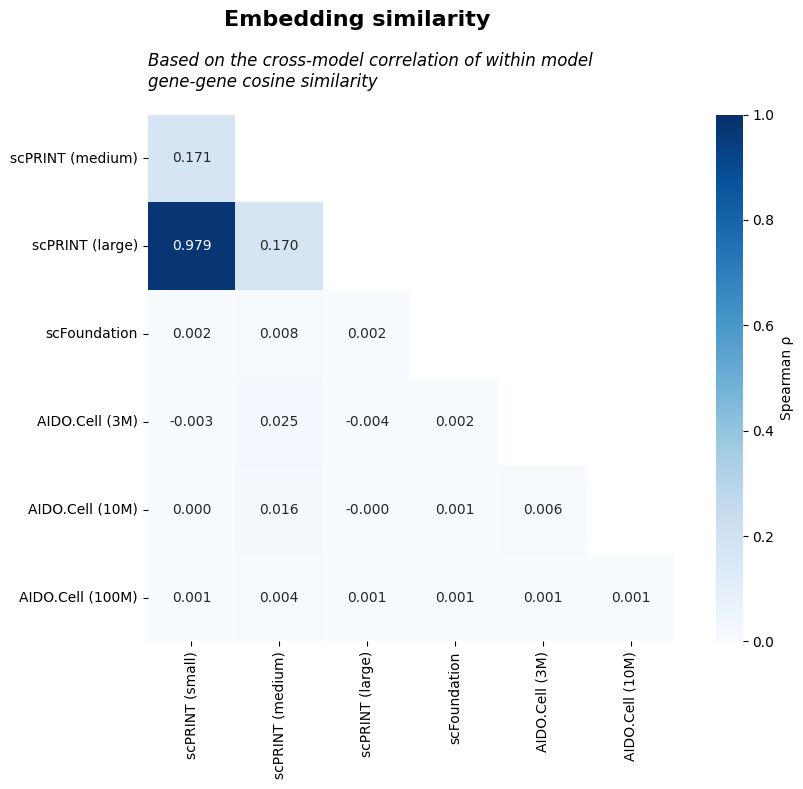

In [8]:
plot_heatmap(
    wide_embeddings_comparisons,
    mask_upper_triangle=True,
    vmax=1,
    vmin=0,
    cbar_label='Spearman ρ',
    suptitle="Embedding similarity",
    title="Based on the cross-model correlation of within model\ngene-gene cosine similarity",
    title_size=12,
    square=True,
    title_fontstyle="italic",
    title_fontweight="normal",
)

plt.show()

## Compare attention

Next, I want to compare the gene-gene attention probabilities (the softmax, makes these a probability distribution for each column) to see how pairs of genes are attending to each other.

### Working with attention summaries

Since Foundation models all use Transformer-based architectural with multiple multi-headed attention layers we can summarize the attention mechanisms either layer-wise or as an aggregate over all layers.

#### From a single layers

At the level of an individual layer, a couple of useful summaries are:

- the raw attention patterns: (gene, gene)
- top-k attention pairs

```python
A_MODEL = "scPRINT (small)"
A_LAYER = 3
ae = attended_embeddings[A_MODEL]

# calculate one layer's attention pattern
attention = ae.compute_attention(layer_idx = A_LAYER, apply_softmax = False)
print(attention.shape)

# pulling out its top-k attention pairs
top_k_attention_edges = ae.get_top_attentions(
    k = TOP_K,
    layer_indices = A_LAYER,
    apply_softmax = False,
    by_absolute_value = BY_ABSOLUTE_VALUE,
)

display(top_k_attention_edges.head())
cleanup_tensors(attention, top_k_attention_edges)
```

Either of these summaries can be rolled up across layers but before doing so we can evaluate whether cross-layer summaries are loosly consistent.

To explore this I'll pull out the top-attention pairs for each layer and compare them across the layers within the same model.

For a single model this can be done with:

```python
# get top-k attention edges for each layer
top_k_attention_edges = (
    attended_embeddings[A_MODEL]
    .get_top_attentions(
        k = 10000,
        by_absolute_value = BY_ABSOLUTE_VALUE,
    )
)

# (gene x gene) summary as attention[arg-max(|attention|)]
(
    attended_embeddings[A_MODEL]
    .compute_consensus_attention(
        consensus_method = CONSENSUS_METHOD
    )
)
```

But, the `FoundationModels` class has convenience methods for aggregating summaries from multiple models.

Here, we'll use the `FoundationModels`'s `get_top_attentions()` to pull out each model x layer's top-K attention scores. A similar method, which will be used later, `get_max_attentions` can be used to create a 3D Tensor of each model's (gene x gene) consensus attention scores.


## Within model - across layers

### Looking at top attention pairs from each layer and model

1. define attention probabilities for each layer (I x I). Where is I is the length and ordering of `common_identifiers`
2. select the N greatest attention probabilities from each layer returning the row and column indices and the attention probability
3. aggregate across all layers and models and store results as a pd.DataFrame
4. rename row/column indices as ensembl genes using `common_identifiers`
5. for each model cound distinct row (from) and column (to) pairs
6. pivot so there is 1 row per from-to edge and columns represent counts of each pair in the top attentions of each model




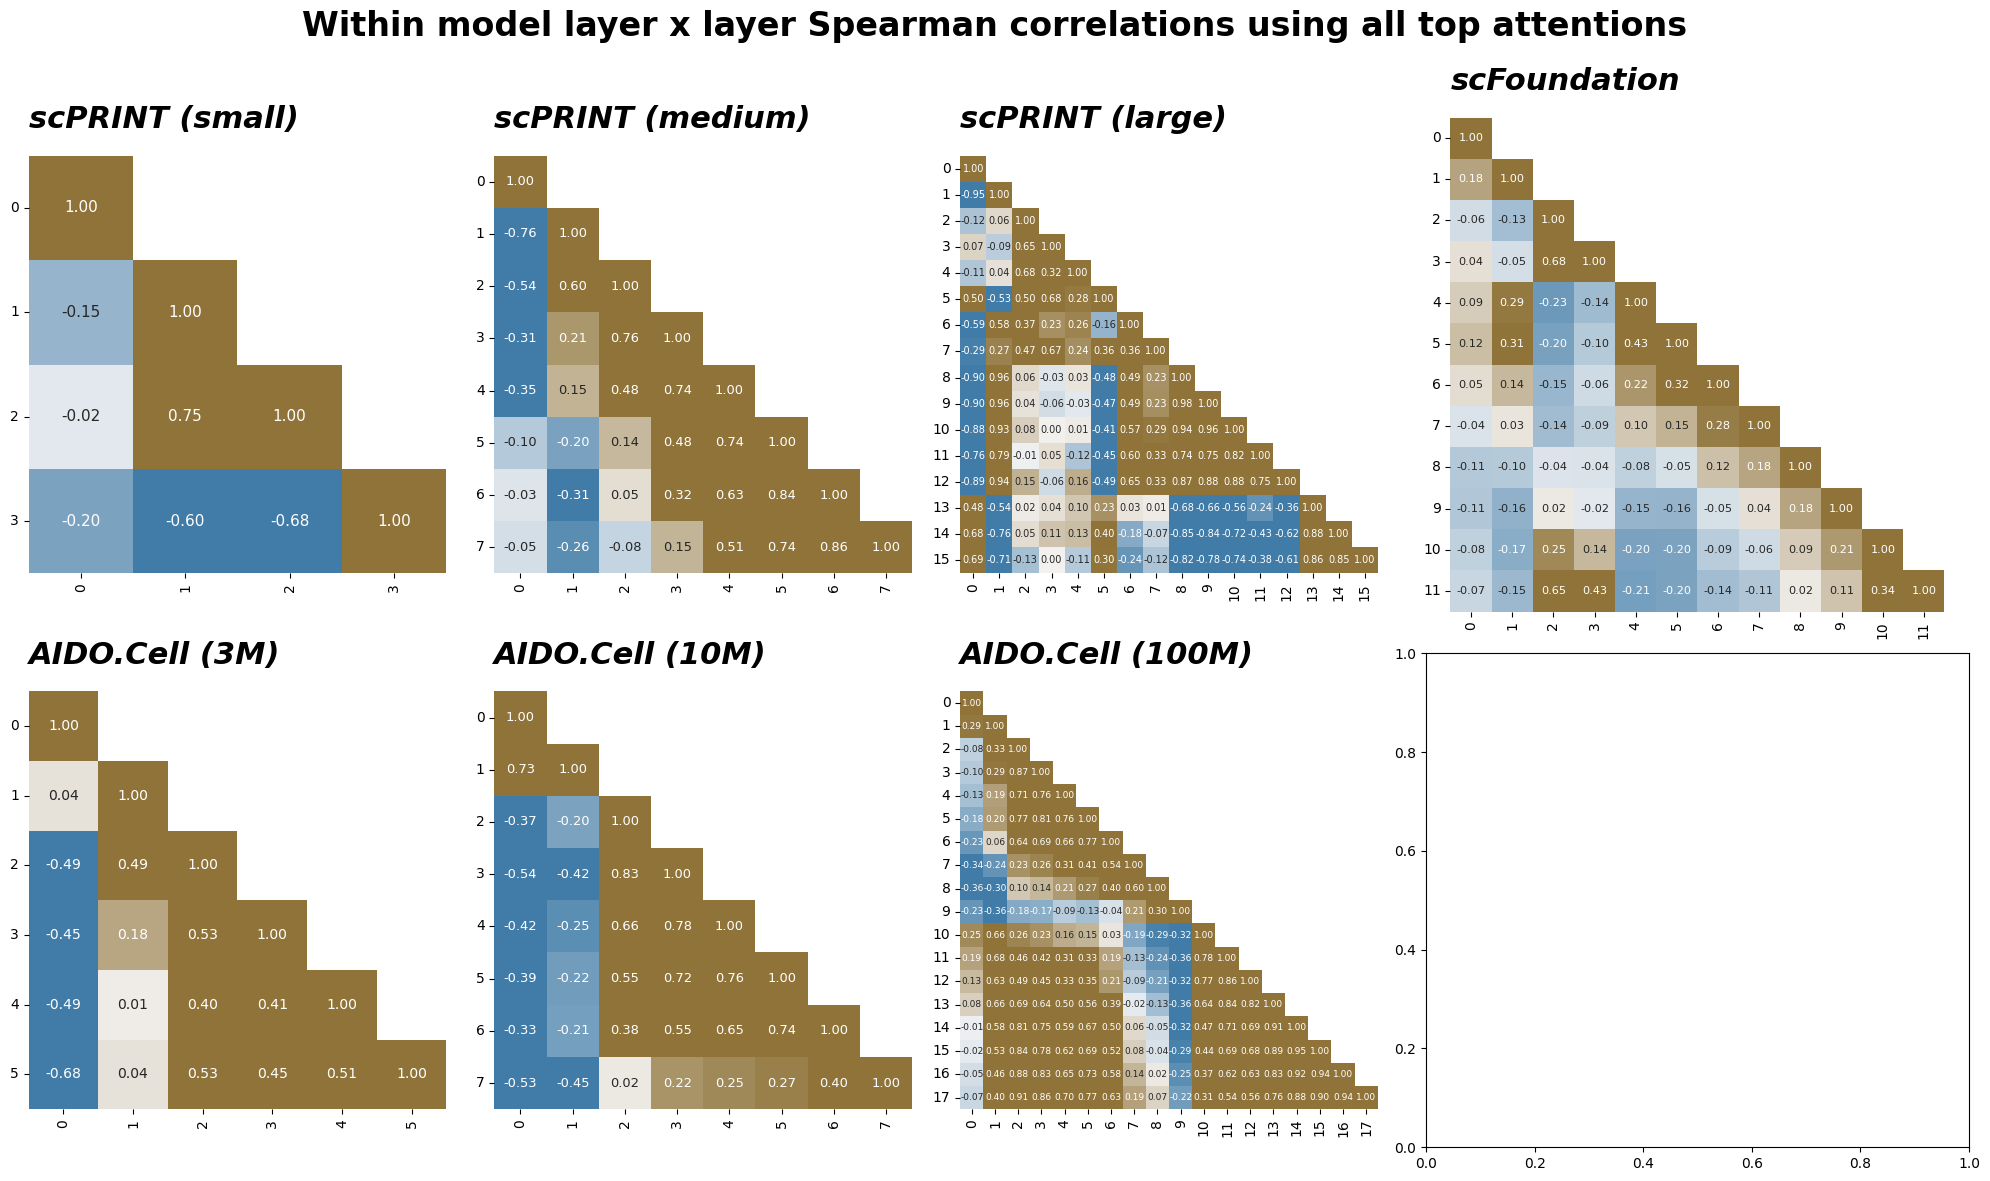

In [9]:
model_layer_correlations = comparisons["model_layer_correlations"]

fig, axes = plt.subplots(2, 4, figsize=(20, 12), gridspec_kw={"width_ratios": [1, 1, 1, 1.3]})
axes = axes.flatten()

for idx, model_name in enumerate(model_order):

    data = model_layer_correlations[model_name]
    annot_size = 15 - 2*np.sqrt(data.shape[0])
    
    plot_heatmap(
        data,
        row_labels = range(data.shape[0]),
        title=model_name,
        cbar=False,
        fmt='.2f',
        vmax=0.3,
        vmin=-0.3,
        cbar_label='Spearman ρ',
        cmap=sns.diverging_palette(240, 60, as_cmap=True),
        mask_upper_triangle=True,
        square=True, 
        title_size=22,
        annot_size=annot_size,
        title_fontstyle="italic",
        ax=axes[idx],
    )

plt.suptitle("Within model layer x layer Spearman correlations using all top attentions", fontsize=24, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



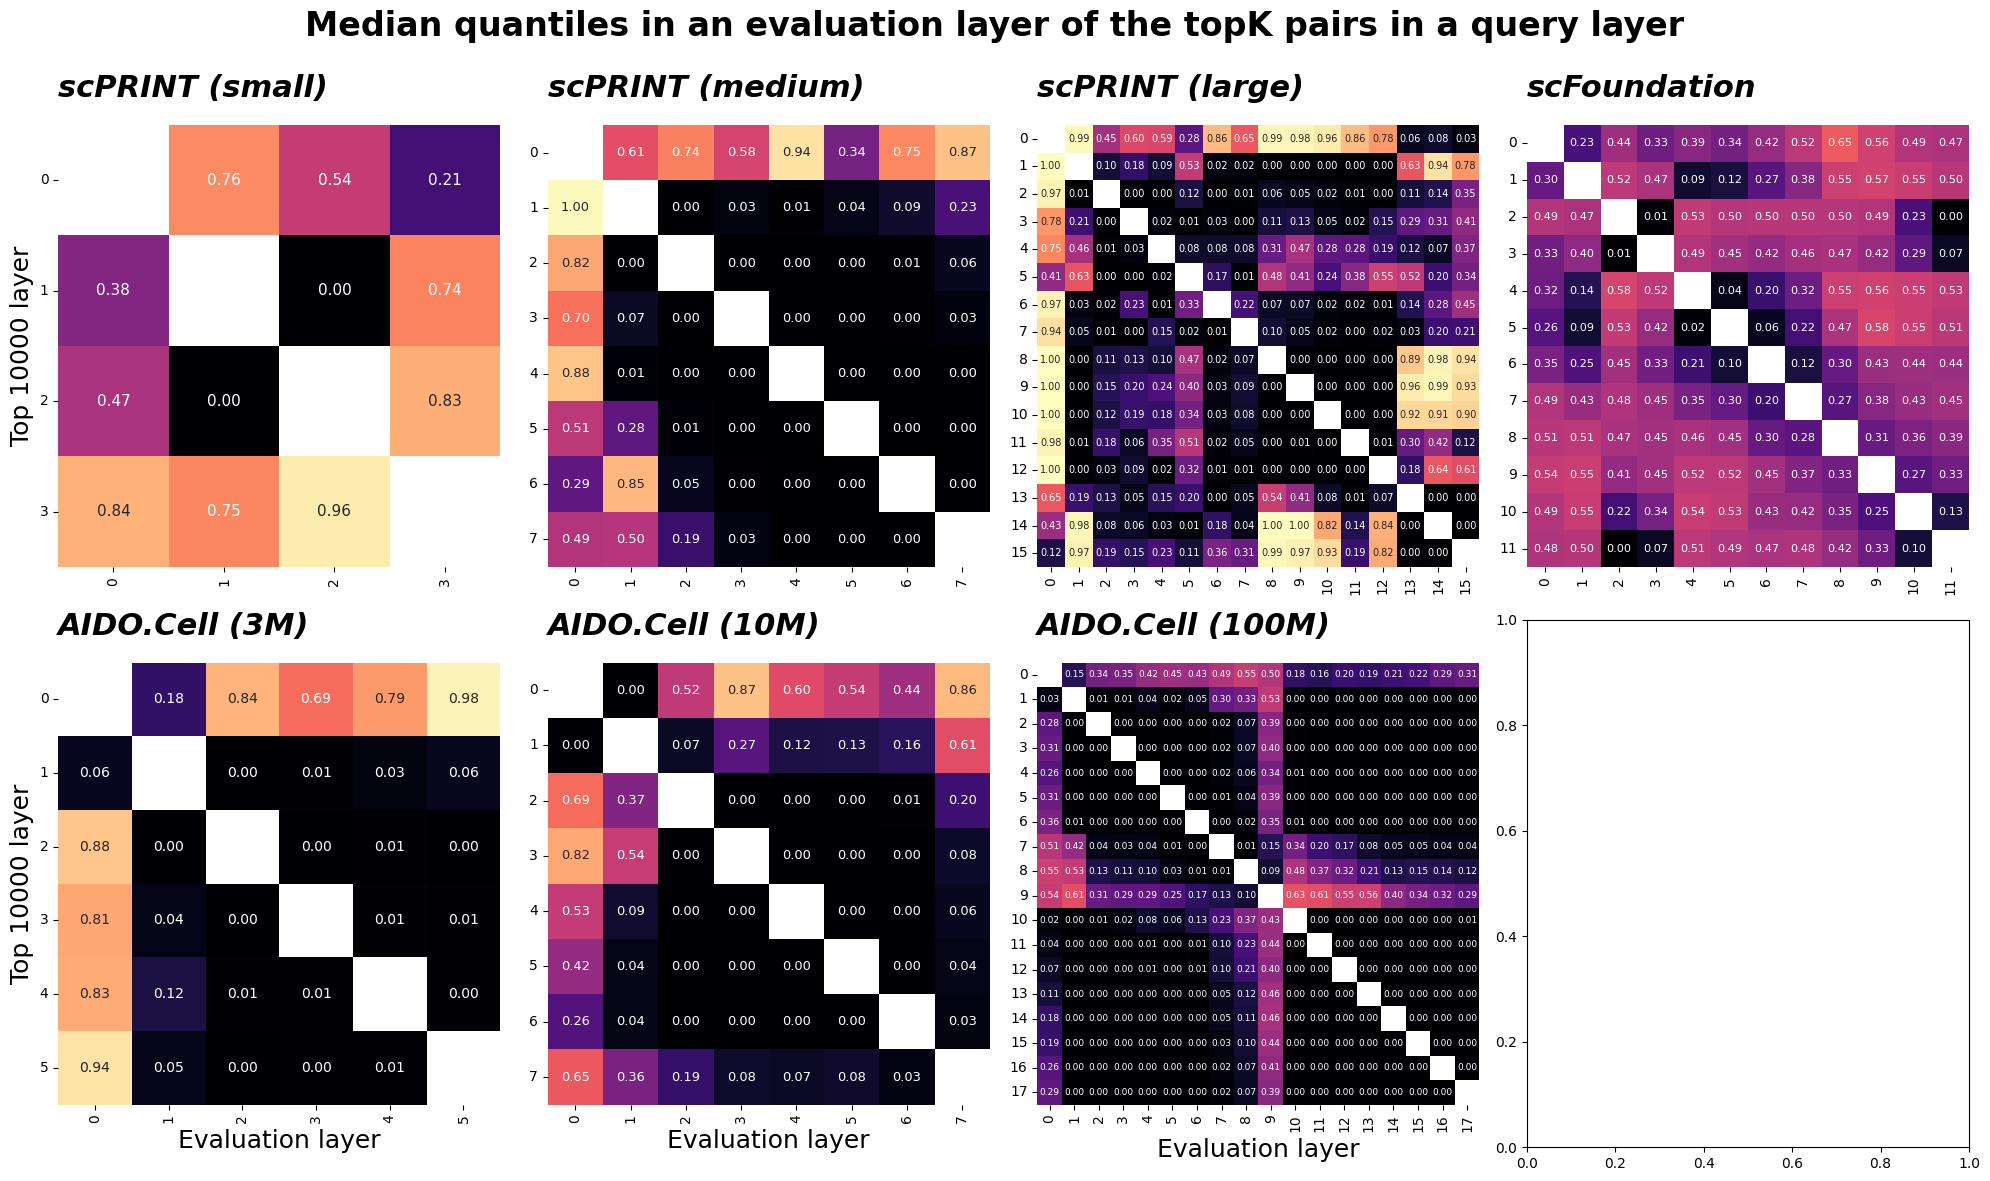

In [10]:
model_layer_rank_agreement = comparisons["model_layer_rank_agreement"]

N_COLUMNS = 4
fig, axes = plt.subplots(2, N_COLUMNS, figsize=(20, 12))
axes = axes.flatten()

for idx, model_name in enumerate(model_order):

    conditional_quantiles = model_layer_rank_agreement[model_name].pivot_table(index = "query_layer", columns = "eval_layer", values = "median_quantile", aggfunc = "median")

    x_title = "Evaluation layer" if idx >= N_COLUMNS else None
    y_title = f"Top {TOP_K} layer" if idx % N_COLUMNS == 0 else None
    annot_size = 15 - 2*np.sqrt(conditional_quantiles.shape[0])
    
    plot_heatmap(
        conditional_quantiles,
        row_labels = range(conditional_quantiles.shape[0]),
        title=model_name,
        xlabel=x_title,
        ylabel=y_title,
        cbar=False,
        cmap="magma",
        fmt='.2f',
        vmax=1,
        vmin=0,
        mask_upper_triangle=False,
        square=True,
        title_size=22,
        axis_title_size=18,
        annot_size=annot_size,
        title_fontstyle="italic",
        ax=axes[idx],
    )

plt.suptitle("Median quantiles in an evaluation layer of the topK pairs in a query layer", fontsize=24, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Across models (all layers)

In [11]:
def calculate_cross_model_attention_correlation(cross_model_top_attentions):

    # look at the top attentions for each model/layer across all models and layers
    wide_consistent_attentions = (
        cross_model_top_attentions.pivot_table(
            index = ["from_gene", "to_gene"],
            columns = ["model", "layer"],
            values = "attention"
        )
    )

    return compute_correlation_matrix(wide_consistent_attentions.to_numpy(), verbose=False)

def get_model_layer_labels(cross_model_top_attentions):

    model_layers_df = cross_model_top_attentions[["model", "layer"]].drop_duplicates()
    model_layers_df["label"] = model_layers_df.apply(lambda x: f"{x['model']}-{x['layer']}", axis=1)

    return model_layers_df


cross_model_top_attentions = comparisons["cross_model_x_layer_top_attentions"]
if "category" in cross_model_top_attentions.columns:
    per_category_corr = cross_model_top_attentions.groupby("category").apply(calculate_cross_model_attention_correlation)
    cross_model_attention_corr = np.median(np.stack(per_category_corr.values), axis=0)
else:
    cross_model_attention_corr = calculate_cross_model_attention_correlation(cross_model_top_attentions)


/var/folders/f1/mcz6x2cj135d8cvtysz3_bfc0000gn/T/ipykernel_96070/3946334526.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_category_corr = cross_model_top_attentions.groupby("category").apply(calculate_cross_model_attention_correlation)


In [12]:

model_layers_df = get_model_layer_labels(cross_model_top_attentions)
model_col_values = model_layers_df["model"]
model_layer_labels = model_layers_df["label"].tolist()

# Create mask where models match (True = mask/hide these values)
mask = model_col_values.to_numpy()[:, None] == model_col_values.to_numpy()[None, :]
assert mask.shape == cross_model_attention_corr.shape

### layer x layer attention correlation

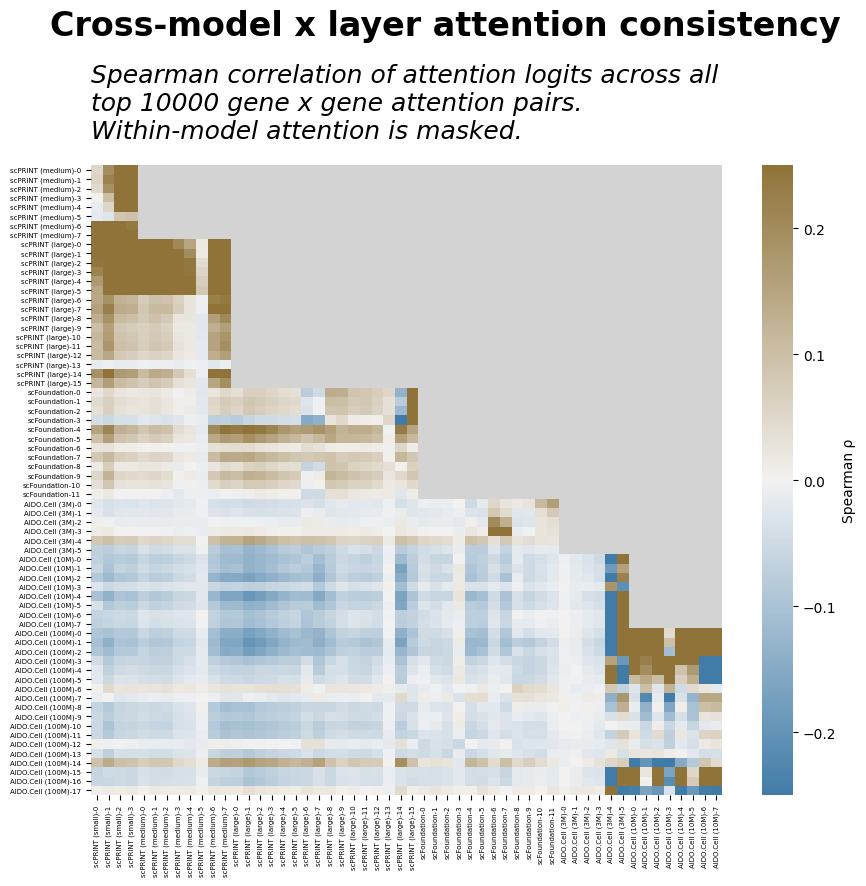

In [13]:
upper_tri_mask = np.triu(np.ones_like(mask, dtype=bool), k=1)
combined_mask = mask | upper_tri_mask

# Find rows and columns that are completely masked (all True)
rows_to_keep = ~combined_mask.all(axis=1)  # Keep rows that have at least one False
cols_to_keep = ~combined_mask.all(axis=0)  # Keep columns that have at least one False

# Filter your data and mask
non_null_cross_model_attention_corr = cross_model_attention_corr[rows_to_keep][:, cols_to_keep]
filtered_mask = combined_mask[rows_to_keep][:, cols_to_keep]

# If you have labels, filter those too
filtered_row_labels = [label for i, label in enumerate(model_layer_labels) if rows_to_keep[i]]
filtered_col_labels = [label for i, label in enumerate(model_layer_labels) if cols_to_keep[i]]

plot_heatmap(
    non_null_cross_model_attention_corr,
    row_labels = filtered_row_labels,
    column_labels = filtered_col_labels,
    suptitle="Cross-model x layer attention consistency",
    title=f"Spearman correlation of attention logits across all\ntop {TOP_K} gene x gene attention pairs.\nWithin-model attention is masked.",
    cmap=sns.diverging_palette(240, 60, as_cmap=True),
    cbar=True,
    fmt='.2f',
    vmax=0.25,
    vmin=-0.25,
    cbar_label='Spearman ρ',
    mask = filtered_mask,
    mask_color='lightgray',
    annot=False,
    tick_label_size=5,
    suptitle_size=24,
    title_size=18,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

In [14]:
triplet_df = (
    pd.DataFrame(
        cross_model_attention_corr,
        index = model_layer_labels,
        columns = model_layer_labels
    )
    .stack()
    .reset_index(name='value')
    .rename(columns={'level_0': 'row', 'level_1': 'col'})
    .query('row > col')  # Lower triangle excluding diagonal
    # expand layer metadata
    .merge(model_layers_df.rename(columns = {"model" : "model1", "layer" : "layer1", "label" : "row"}))
    .merge(model_layers_df.rename(columns = {"model" : "model2", "layer" : "layer2", "label" : "col"}))
)

triplet_df.query('model1 != model2').sort_values('value', ascending = True).head(10)

,row,col,value,model1,layer1,model2,layer2
2180,AIDO.Cell (3M)-4,AIDO.Cell (10M)-6,-0.808363,AIDO.Cell (3M),4,AIDO.Cell (10M),6
2181,AIDO.Cell (3M)-4,AIDO.Cell (10M)-7,-0.807122,AIDO.Cell (3M),4,AIDO.Cell (10M),7
2182,AIDO.Cell (3M)-4,AIDO.Cell (100M)-0,-0.772036,AIDO.Cell (3M),4,AIDO.Cell (100M),0
2184,AIDO.Cell (3M)-4,AIDO.Cell (100M)-2,-0.737935,AIDO.Cell (3M),4,AIDO.Cell (100M),2
2183,AIDO.Cell (3M)-4,AIDO.Cell (100M)-1,-0.689786,AIDO.Cell (3M),4,AIDO.Cell (100M),1
2198,AIDO.Cell (3M)-4,AIDO.Cell (100M)-16,-0.680092,AIDO.Cell (3M),4,AIDO.Cell (100M),16
2178,AIDO.Cell (3M)-4,AIDO.Cell (10M)-4,-0.594036,AIDO.Cell (3M),4,AIDO.Cell (10M),4
2197,AIDO.Cell (3M)-4,AIDO.Cell (100M)-15,-0.575761,AIDO.Cell (3M),4,AIDO.Cell (100M),15
2365,AIDO.Cell (10M)-6,AIDO.Cell (100M)-5,-0.546090,AIDO.Cell (10M),6,AIDO.Cell (100M),5
2364,AIDO.Cell (10M)-6,AIDO.Cell (100M)-4,-0.538411,AIDO.Cell (10M),6,AIDO.Cell (100M),4


### Layer x layer rank consistency 

In [15]:
model_x_layer_rank_agreement = comparisons["cross_model_x_layer_rank_agreement"]

# [0,1] low quantiles are more consistent (ranks in attent B | top in A)
conditional_quantiles = (
    model_x_layer_rank_agreement
    .pivot_table(
        index = ["query_model", "query_layer"],
        columns = ["eval_model", "eval_layer"],
        values = "median_quantile",
        aggfunc = "median"
    )
)

# Reorder to match model/layer ordering from wide_consistent_attentions
reordered_index = reorder_multindex_by_categorical_and_numeric(
    conditional_quantiles.index,
    categorical_order=model_order,
    categorical_level=0,  # query_model
    numeric_level=1       # query_layer
)

# Get categorical order (model order) from reference
# Reorder index and columns
conditional_quantiles = conditional_quantiles.reindex(
    index=reordered_index,
    columns=reordered_index
)

# mask within-model block diagonal
model_col_values = conditional_quantiles.columns.get_level_values(0)

# Create mask where models match (True = mask/hide these values)
mask = model_col_values.to_numpy()[:, None] == model_col_values.to_numpy()[None, :]


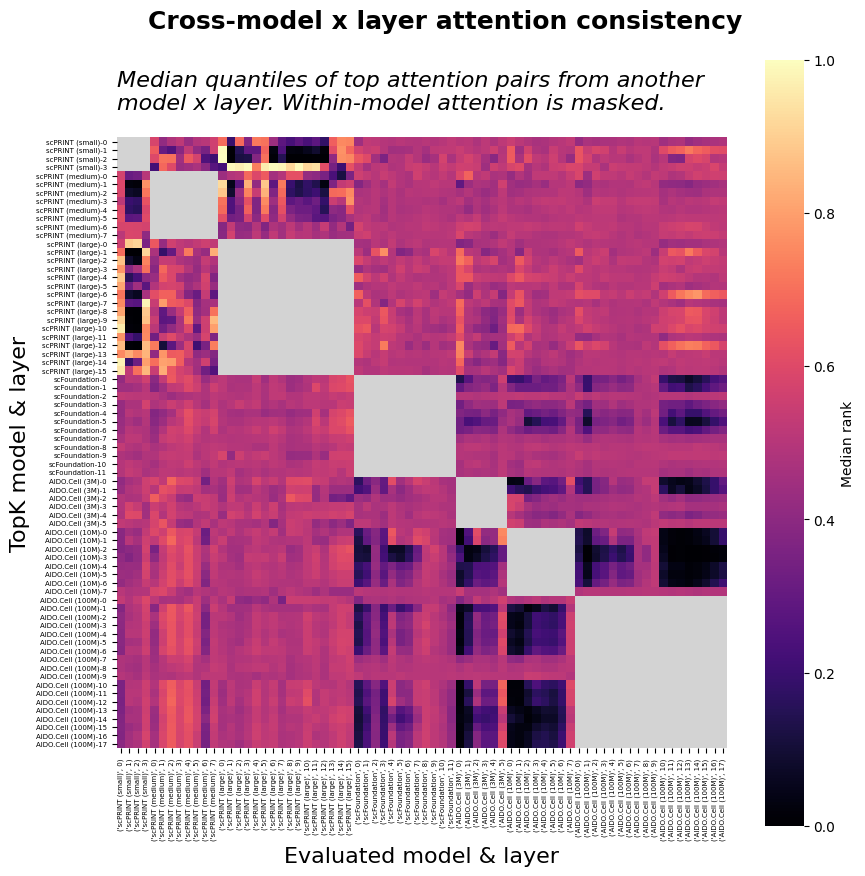

In [16]:
plot_heatmap(
    conditional_quantiles,
    row_labels = model_layer_labels,
    suptitle="Cross-model x layer attention consistency",
    title="Median quantiles of top attention pairs from another\nmodel x layer. Within-model attention is masked.",
    xlabel = "Evaluated model & layer",
    ylabel = "TopK model & layer",
    cmap='magma',
    cbar=True,
    fmt='.2f',
    vmax=1,
    vmin=-0,
    cbar_label='Median rank',
    mask = mask,
    mask_upper_triangle=False,
    mask_color='lightgray',
    annot=False,
    square=True,
    suptitle_size=18,
    title_size=16,
    axis_title_size=16,
    tick_label_size=5,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

In [17]:
max_cross_model_layer_agreement = model_x_layer_rank_agreement.query('query_model != eval_model').sort_values('median_quantile', ascending = True).groupby(['eval_model', 'query_model']).first()
max_cross_model_layer_agreement

query_layer  eval_layer  mean_quantile  \
eval_model       query_model                                                
AIDO.Cell (100M) AIDO.Cell (10M)             2          14       0.089086   
                 AIDO.Cell (3M)              0          12       0.224909   
                 scFoundation                0          13       0.191316   
                 scPRINT (large)            10          13       0.378846   
                 scPRINT (medium)            1          13       0.381521   
                 scPRINT (small)             2          12       0.367583   
AIDO.Cell (10M)  AIDO.Cell (100M)           10           1       0.121026   
                 AIDO.Cell (3M)              0           1       0.104526   
                 scFoundation                4           2       0.237529   
                 scPRINT (large)             1           1       0.340109   
                 scPRINT (medium)            1           1       0.422927   
                 scPRINT (small)             1           1       0.420483   
AIDO.Cell (3M)   AIDO.Cell (100M)           11           0       0.127098   
                 AIDO.Cell (10M)             0           0       0.099383   
                 scFoundation                0           0       0.187546   
                 scPRINT (large)            12           4       0.342015   
                 scPRINT (medium)            1           0       0.330085   
                 scPRINT (small)             2           4       0.409730   
scFoundation     AIDO.Cell (100M)           13           0       0.208841   
                 AIDO.Cell (10M)             2           4       0.124122   
                 AIDO.Cell (3M)              0           0       0.231395   
                 scPRINT (large)             1           5       0.383517   
                 scPRINT (medium)            1           0       0.395051   
                 scPRINT (small)             2           3       0.403727   
scPRINT (large)  AIDO.Cell (100M)           10           1       0.265879   
                 AIDO.Cell (10M)             0           1       0.207661   
                 AIDO.Cell (3M)              0           0       0.310455   
                 scFoundation                0           8       0.384728   
                 scPRINT (medium)            1          12       0.081804   
                 scPRINT (small)             2           1       0.002206   
scPRINT (medium) AIDO.Cell (100M)           14           6       0.305192   
                 AIDO.Cell (10M)             0           6       0.305301   
                 AIDO.Cell (3M)              0           6       0.365236   
                 scFoundation                4           0       0.335036   
                 scPRINT (large)            12           1       0.189458   
                 scPRINT (small)             2           7       0.395691   
scPRINT (small)  AIDO.Cell (100M)           12           0       0.217004   
                 AIDO.Cell (10M)             0           2       0.211382   
                 AIDO.Cell (3M)              0           0       0.323608   
                 scFoundation                3           0       0.345790   
                 scPRINT (large)             1           1       0.000834   
                 scPRINT (medium)            1           2       0.043472   

                                   median_quantile  min_quantile  \
eval_model       query_model                                       
AIDO.Cell (100M) AIDO.Cell (10M)          0.000976  3.045675e-09   
                 AIDO.Cell (3M)           0.008153  1.072078e-06   
                 scFoundation             0.012265  2.741108e-08   
                 scPRINT (large)          0.316381  4.629640e-04   
                 scPRINT (medium)         0.341015  1.317507e-03   
                 scPRINT (small)          0.315219  4.296869e-04   
AIDO.Cell (10M)  AIDO.Cell (100M)         0.002833  5.177648e-08   
                 AIDO.Cell (3M)   

## Across models (comparing cross-layer model consensus attentions)

In [18]:
def calculate_cross_model_consensus_attention_correlation(consensus_top_k):

    # look at the top attentions for each model/layer across all models and layers
    wide_consensus_top_k = (
        consensus_top_k.pivot(index = ["from_gene", "to_gene"], columns = "model", values = "attention")
        .reindex(columns=model_order)
    )

    return compute_correlation_matrix(wide_consensus_top_k.to_numpy())

consensus_top_k = comparisons["cross_model_consensus_top_attentions"]
if "category" in consensus_top_k.columns:
    per_category_corr = consensus_top_k.groupby("category").apply(calculate_cross_model_consensus_attention_correlation)
    cross_model_attention_corr = np.median(np.stack(per_category_corr.values), axis=0)
else:
    cross_model_attention_corr = calculate_cross_model_consensus_attention_correlation(cross_model_top_attentions)

/var/folders/f1/mcz6x2cj135d8cvtysz3_bfc0000gn/T/ipykernel_96070/3590312217.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_category_corr = consensus_top_k.groupby("category").apply(calculate_cross_model_consensus_attention_correlation)


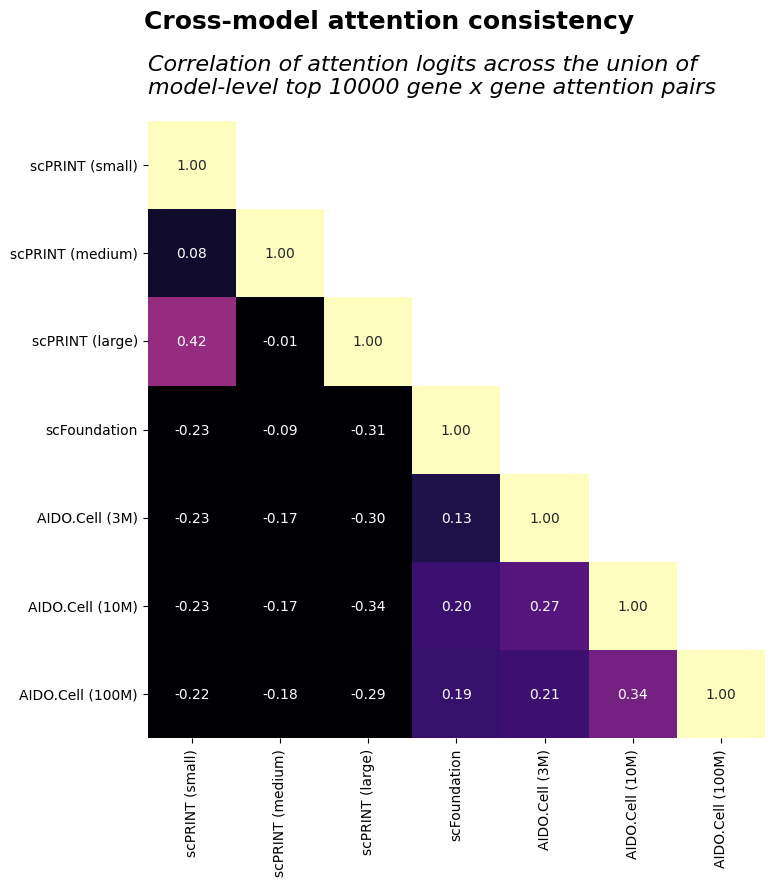

In [19]:
plot_heatmap(
    cross_model_attention_corr,
    row_labels = consensus_top_k["model"].unique(),
    suptitle="Cross-model attention consistency",
    title=f"Correlation of attention logits across the union of\nmodel-level top {TOP_K} gene x gene attention pairs",
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=1,
    vmin=0,
    mask_upper_triangle=True,
    annot=True,
    square=True,
    suptitle_size=18,
    title_size=16,
    axis_title_size=16,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

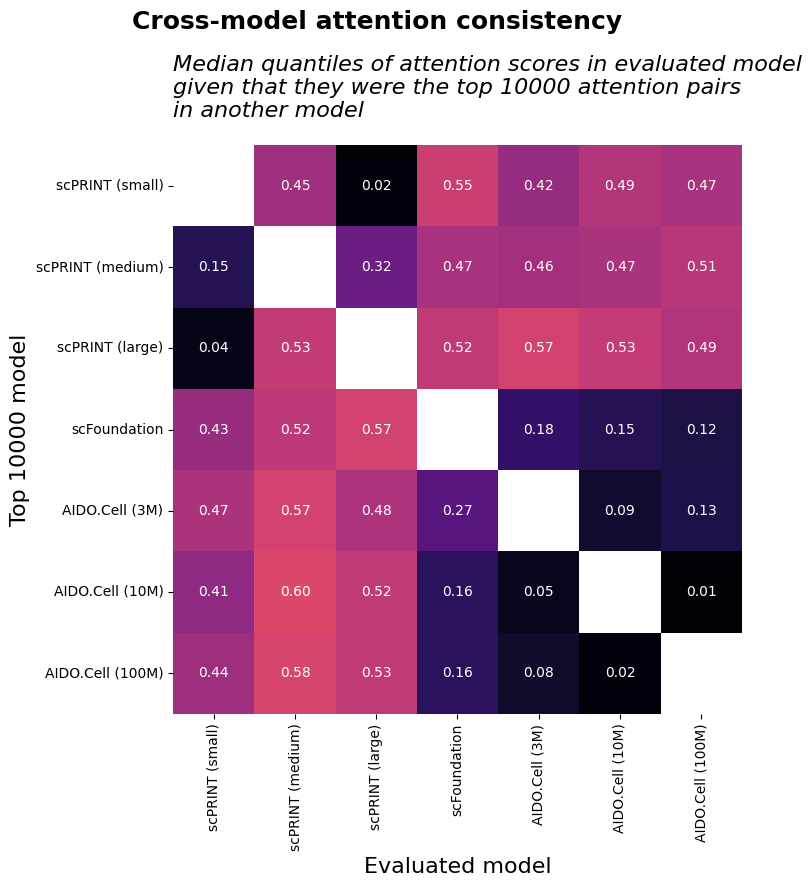

In [20]:
conditional_quantiles = (
    comparisons["cross_model_consensus_top_attentions_rank_agreement"]
    .pivot_table(
        index = ["query_model"],
        columns = ["eval_model"],
        values = "median_quantile",
        aggfunc = "median"
    )
    .reindex(index=model_order, columns=model_order)
)

plot_heatmap(
    conditional_quantiles,
    row_labels = conditional_quantiles.columns.tolist(),
    column_labels = conditional_quantiles.index.tolist(),
    suptitle=f"Cross-model attention consistency",
    title=f"Median quantiles of attention scores in evaluated model\ngiven that they were the top {TOP_K} attention pairs\nin another model",
    xlabel = "Evaluated model",
    ylabel = f"Top {TOP_K} model",
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=1,
    vmin=0,
    cbar_label='Rank aggreement',
    mask_upper_triangle=False,
    annot=True,
    square=True,
    suptitle_size=18,
    title_size=16,
    axis_title_size=16,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

## Summarize attention pairs as edgelist

In [21]:
from napistu_torch.evaluation.manager import RemoteEvaluationManager

In [22]:
select_query_layers = max_cross_model_layer_agreement.reset_index().value_counts(["query_model", "query_layer"]).iloc[0:3]
# look at the evaluation layers whose ranks most agree with the selected query layers
max_cross_model_layer_agreement.reset_index().merge(select_query_layers.reset_index(), on=['query_model', 'query_layer']).set_index(['query_model', 'query_layer']).sort_index()

eval_model  eval_layer  mean_quantile  \
query_model      query_layer                                                
AIDO.Cell (3M)   0            AIDO.Cell (100M)          12       0.224909   
                 0             AIDO.Cell (10M)           1       0.104526   
                 0                scFoundation           0       0.231395   
                 0             scPRINT (large)           0       0.310455   
                 0            scPRINT (medium)           6       0.365236   
                 0             scPRINT (small)           0       0.323608   
scPRINT (medium) 1            AIDO.Cell (100M)          13       0.381521   
                 1             AIDO.Cell (10M)           1       0.422927   
                 1              AIDO.Cell (3M)           0       0.330085   
                 1                scFoundation           0       0.395051   
                 1             scPRINT (large)          12       0.081804   
                 1             scPRINT (small)           2       0.043472   
scPRINT (small)  2            AIDO.Cell (100M)          12       0.367583   
                 2              AIDO.Cell (3M)           4       0.409730   
                 2                scFoundation           3       0.403727   
                 2             scPRINT (large)           1       0.002206   
                 2            scPRINT (medium)           7       0.395691   

                              median_quantile  min_quantile  max_quantile  \
query_model      query_layer                                                
AIDO.Cell (3M)   0                   0.008153  1.072078e-06      1.000000   
                 0                   0.007219  4.355316e-07      0.999689   
                 0                   0.064421  7.340078e-07      0.999989   
                 0                   0.203823  4.297448e-06      0.999841   
                 0                   0.274987  2.542378e-04      0.999681   
                 0                   0.242977  3.996017e-04      0.999194   
scPRINT (medium) 1                   0.341015  1.317507e-03      0.997728   
                 1                   0.376746  3.788181e-04      0.999865   
                 1                   0.242239  2.956437e-05      0.999793   
                 1                   0.356596  2.203759e-04      0.999190   
                 1                   0.030890  2.244358e-05      0.997356   
                 1                   0.015812  1.591944e-04      0.968685   
scPRINT (small)  2                   0.315219  4.296869e-04      0.998382   
                 2                   0.374509  7.315042e-04      0.999494   
                 2                   0.346661  2.176126e-03      0.999736   
                 2                   0.000344  1.340097e-07      0.050878   
                 2                   0.204734  4.455214e-05      0.999989   

                               statistic        p_value  \
query_model      query_layer                              
AIDO.Cell (3M)   0             6554377.0   0.000000e+00   
                 0              986553.0   0.000000e+00   
                 0             5991065.0   0.000000e+00   
                 0            10333980.0   0.000000e+00   
                 0            13162152.0   0.000000e+00   
                 0             9113081.0   0.000000e+00   
scPRINT (medium) 1            13052562.0   0.000000e+00   
                 1            17695677.0  2.499363e-141   
                 1            10663311.0   0.000000e+00   
                 1            14759837.0  1.037604e-275   
                 1              248928.0   0.000000e+00   
                 1               24133.0   0.000000e+00   
scPRINT (small)  2            12289523.0   0.000000e+00   
                 2            15890660.0  6.023144e-218   
                 2            15429552.0  3.237288e-240   
                 2                   0.0   0.000000e+00   
                 2            17405377.5  7.46

In [23]:
# look at the topK attentions for the selected layers
top_k_select_attentions = (
    cross_model_top_attentions.merge(
        (
            select_query_layers.reset_index()
            .drop(columns = ["count"])
            .rename(columns = {"query_model" : "model", "query_layer" : "layer"})
        ),
        on=["model", "layer"],
        how = "inner"
    )
    .query("attention_rank <= @TOP_K")
    .set_index(["model", "layer"])
    .sort_values("attention_rank")
    .sort_index()
)

# filter to just the from-to genes for the top attentions
top_k_select_attention_gene_edgelist = top_k_select_attentions[["from_gene", "to_gene"]].drop_duplicates()

In [24]:

def add_vertex_names_to_edgelist(
    top_k_select_attention_gene_edgelist,
    gene_to_vertex_map
):

    top_k_with_ids = (
        top_k_select_attention_gene_edgelist
        .merge(
            (
                gene_to_vertex_map
                .rename(columns = {"ensembl_gene" : "from_gene", "name" : "from_vertex"})
                .drop(columns = ["s_id"])
            ),
            on = "from_gene",
            how = "left"
        )
        .merge(
            gene_to_vertex_map
            .rename(columns = {"ensembl_gene" : "to_gene", "name" : "to_vertex"})
            .drop(columns = ["s_id"]),
            on = "to_gene",
            how = "left"
        )
    )

    # drop NAs and log
    invalid_edges = top_k_with_ids.isna().any(axis = 1)
    if invalid_edges.sum() > 0:
        percent_invalid = (invalid_edges.sum() / len(top_k_with_ids)) * 100
        logger.warning(f"Dropping {invalid_edges.sum()} edges ({percent_invalid:.2f}%) which could not be mapped to vertices")

    return top_k_with_ids.loc[~invalid_edges]

gene_to_vertex_map = map_identifiers_to_vertex_names(gene_ids, species_identifiers, name_to_sid_map)

focused_attention_edgelist = add_vertex_names_to_edgelist(
    top_k_select_attention_gene_edgelist,
    gene_to_vertex_map
)

INFO:napistu_torch.utils.napistu_utils:128 (0.7%) identifiers were missing from the ensembl_gene identifiers in the species identifiers table. These ids will be missing in the output.


## Load models

In [98]:
evaluation_manager = RemoteEvaluationManager.from_huggingface(
    "seanhacks/edge_prediction_mlp_256e",
    data_store_dir = STORE_DIR
)
napistu_gnn = evaluation_manager.load_model_from_checkpoint()
napistu_data = evaluation_manager.load_napistu_data()


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


In [99]:
# find the indices of the edges in the NapistuData object
edge_indices = napistu_data.get_edge_indices(focused_attention_edgelist, "from_vertex", "to_vertex")
task = napistu_gnn.task
predictions = task.predict_edge_scores(
    data=napistu_data,
    edge_index=edge_indices,
)

focused_attention_edgelist["prediction"] = predictions
focused_attention_edgelist["direct_edge_exists"] = napistu_data.has_edges(edge_indices)

In [53]:
import torch

In [ ]:
# Get the gene vertex indices
gene_vertices = set(napistu_data.get_vertex_indices(gene_to_vertex_map["name"]))

# edge_index shape: [2, num_edges]
src = napistu_data.edge_index[0]
dst = napistu_data.edge_index[1]

# Mask edges where both endpoints are in the gene vertex set
gene_vertices_tensor = torch.tensor(list(gene_vertices), dtype=torch.long)

src_mask = torch.isin(src, gene_vertices_tensor)
dst_mask = torch.isin(dst, gene_vertices_tensor)

both_mask = src_mask & dst_mask
num_edges = both_mask.sum().item()

# density of edges among genes in the vocabulary
background_edge_rate = num_edges / (len(gene_vertices)-1) ** 2

In [88]:
# calculate the average edge score for all edges in the universe
all_pairs = pd.MultiIndex.from_product(
    [gene_to_vertex_map["name"], gene_to_vertex_map["name"]], names=["from", "to"]
).to_frame(index=False)
all_pairs = all_pairs[all_pairs["from"] != all_pairs["to"]]
# randomly subset since we are just interested in the average score
all_pairs = all_pairs.sample(10000)

background_average_edge_score = task.predict_edge_scores(
    napistu_data,
    napistu_data.get_edge_indices(all_pairs, "from", "to")
).mean().numpy()

In [27]:
all_topk_attention_gene_edgelist = (
    comparisons["cross_model_x_layer_top_attentions"]
    .query("attention_rank <= @TOP_K")
)

distinct_topk_attention_gene_edgelist = all_topk_attention_gene_edgelist[["from_gene", "to_gene"]].drop_duplicates()

distinct_topk_attention_gene_edgelist = add_vertex_names_to_edgelist(
    distinct_topk_attention_gene_edgelist,
    gene_to_vertex_map
)

In [ ]:
edge_indices = napistu_data.get_edge_indices(distinct_topk_attention_gene_edgelist, "from_vertex", "to_vertex")
task = napistu_gnn.task
predictions = task.predict_edge_scores(
    data=napistu_data,
    edge_index=edge_indices,
)

distinct_topk_attention_gene_edgelist["prediction"] = predictions
distinct_topk_attention_gene_edgelist["direct_edge_exists"] = napistu_data.has_edges(edge_indices)

In [66]:
curated_top_edges = all_topk_attention_gene_edgelist.merge(
    distinct_topk_attention_gene_edgelist[["from_gene", "to_gene", "prediction", "direct_edge_exists"]],
    on = ["from_gene", "to_gene"],
    how = "left"
)

direct_edge_rate = (
    curated_top_edges.value_counts(["model", "layer", "category", "direct_edge_exists"])
    .reset_index()
    .pivot(index = ["model", "layer", "category"], columns = "direct_edge_exists", values = "count")
    .fillna(0)
    .assign(true_fraction = lambda x: x[True] / x.sum(axis = 1))
    .reset_index()
    .assign(model_name = lambda x: pd.Categorical(
        x['model'], 
        categories=model_order, 
        ordered=True
    ))
)

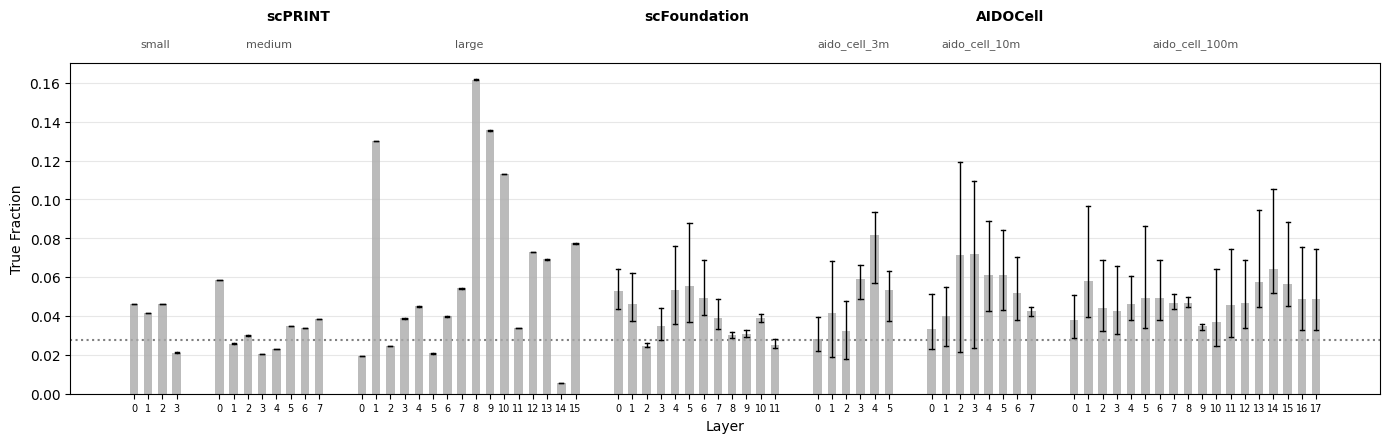

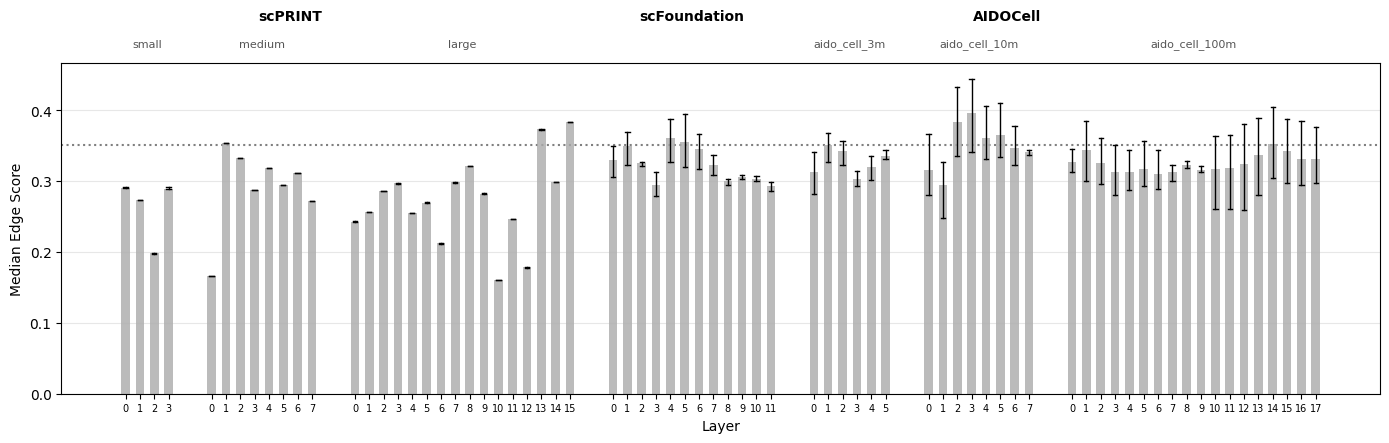

In [ ]:
def get_model_label_maps(model_metadata_summary):
    model_type_map = model_metadata_summary.set_index('model')['model type'].to_dict()
    model_variant_map = model_metadata_summary.set_index('model')['model variant'].to_dict()
    return model_type_map, model_variant_map

def plot_metric_by_layer(
    data,
    y_col,
    background_value,
    ylabel,
    model_order,
    model_metadata_summary,
    figsize=(14, 4),
    bar_width=0.6,
    group_gap=2,
):

    model_type_map, model_variant_map = get_model_label_maps(model_metadata_summary)
    fig, ax = plt.subplots(figsize=figsize)

    x_pos_map = {}
    current_x = 0
    model_label_positions = {}

    for model in model_order:
        model_data = data[data['model_name'] == model]
        layers = sorted(model_data['layer'].unique())
        model_start = current_x

        for layer in layers:
            x_pos_map[(model, layer)] = current_x
            current_x += 1

        model_label_positions[model] = (model_start + current_x - 1) / 2
        current_x += group_gap

    for model in model_order:
        model_data = data[data['model_name'] == model]

        for layer, group in model_data.groupby('layer'):
            x = x_pos_map[(model, layer)]
            mean_val = group[y_col].mean()
            min_val = group[y_col].min()
            max_val = group[y_col].max()

            ax.bar(x, mean_val, width=bar_width, color='#aaaaaa', alpha=0.8)
            ax.plot([x, x], [min_val, max_val], color='black', linewidth=1, zorder=5)
            ax.plot([x - 0.15, x + 0.15], [min_val, min_val], color='black', linewidth=1, zorder=5)
            ax.plot([x - 0.15, x + 0.15], [max_val, max_val], color='black', linewidth=1, zorder=5)

    ax.set_xticks([x_pos_map[(m, l)] for m in model_order
                   for l in sorted(data[data['model_name'] == m]['layer'].unique())])
    ax.set_xticklabels([str(l) for m in model_order
                        for l in sorted(data[data['model_name'] == m]['layer'].unique())],
                       fontsize=7)

    ax.axhline(background_value, color='gray', linestyle=':', linewidth=1.5, zorder=0)
    ax.set_xlabel('Layer')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    y_max = ax.get_ylim()[1]
    y_type = y_max * 1.12
    y_variant = y_max * 1.04

    seen_types = {}
    for model, x_center in model_label_positions.items():
        model_type = model_type_map.get(model, model)
        variant = model_variant_map.get(model)

        if model_type not in seen_types:
            seen_types[model_type] = []
        seen_types[model_type].append(x_center)

        if pd.notna(variant):
            ax.text(x_center, y_variant, variant, ha='center', va='bottom',
                    fontsize=8, color='#555555')

    for model_type, positions in seen_types.items():
        x_center = np.mean(positions)
        ax.text(x_center, y_type, model_type, ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    return fig, ax


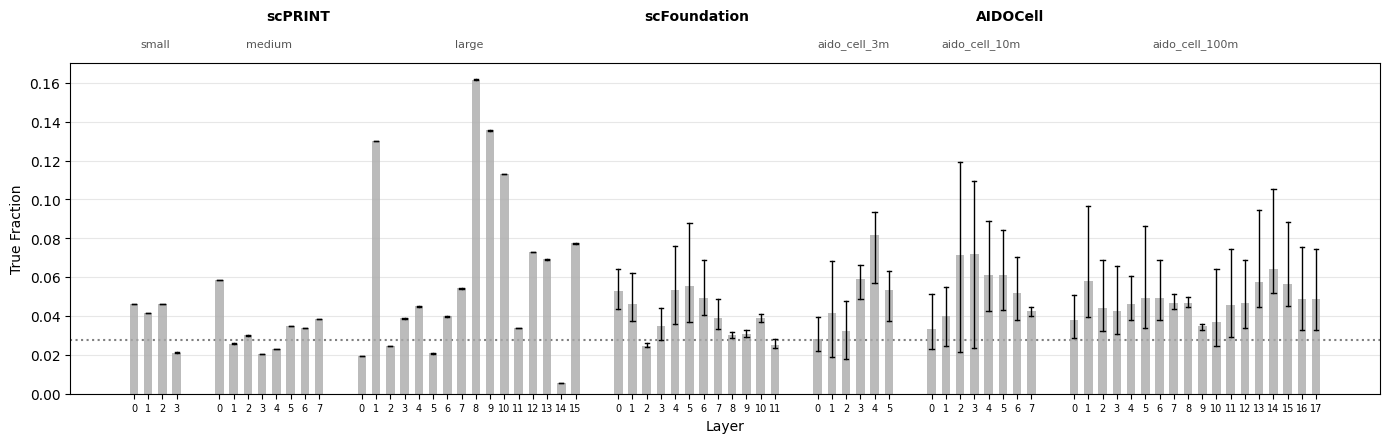

In [93]:
fig, ax = plot_metric_by_layer(
    data=direct_edge_rate,
    y_col='true_fraction',
    background_value=background_edge_rate,
    ylabel='True Fraction',
    model_order=model_order,
    model_metadata_summary=model_metadata_summary,
)

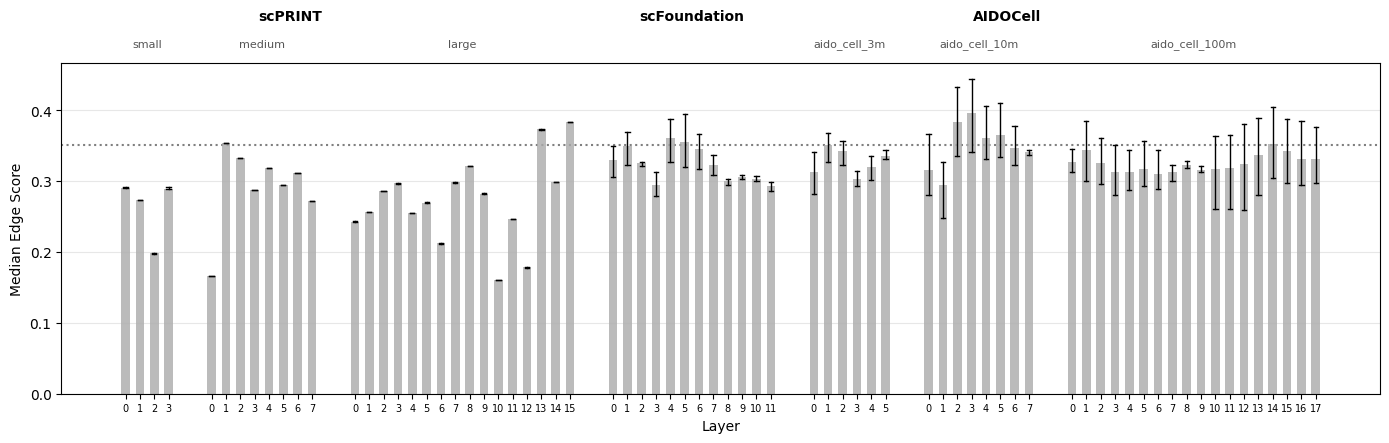

In [92]:
average_edge_prediction = (
    curated_top_edges
    .groupby(["model", "layer", "category"])["prediction"]
    .median()
    .reset_index()
    .assign(model_name = lambda x: x["model"])
    .assign(model_name = lambda x: pd.Categorical(
        x['model_name'], 
        categories=model_order, 
        ordered=True
    ))
)

# average predictions for the layers with the highest cross-model rank agreement
max_cross_model_layer_agreement_w_edge_predictions = (
    select_query_layers
    .reset_index()
    .merge(
        average_edge_prediction
        .rename(columns = {"model" : "query_model", "layer" : "query_layer", "prediction" : "query_avg_edge_prediction"}),
        on = ["query_model", "query_layer"],
        how = "inner"
    )
)


fig, ax = plot_metric_by_layer(
    data=average_edge_prediction,
    y_col='prediction',
    background_value=background_average_edge_score,
    ylabel='Median Edge Score',
    model_order=model_order,
    model_metadata_summary=model_metadata_summary,
)


## What do the high scoring edges represent?

In [ ]:
# if scores are low, then are high attention edges preferentially between distant genes?


In [ ]:
# load the model's vertex embeddings

vertex_embeddings = napistu_gnn.get_embeddings(napistu_data)

gene_vertices

In [112]:
from napistu_torch.utils.tensor_utils import compute_cosine_distances_torch

In [113]:
cosine_sim = 1 - compute_cosine_distances_torch(vertex_embeddings)

: 

In [ ]:
vertex_embeddings